## 07 Climate Projections: Agricultural Implications for SD Tribal Lands
**Series:** Tribal Agriculture & Land Health in South Dakota  
**Author:** Lilly Jones, PhD  
**Primary Focus:** Oglala Lakota (Pine Ridge), Sicangu Lakota (Rosebud)  
**In Scope:** All South Dakota Tribal Nations  
**Data Sources:** MACAv2-METDATA climate projections (Northwest Knowledge Network)

## Purpose
Notebooks 02–06 characterize historical conditions. This notebook completes
the series by asking: **where are those conditions going?**
For Tribal agricultural planning on Pine Ridge and Rosebud, the most
consequential projected changes are:
- Rising growing season temperatures can lead to increasing heat stress on livestock
  and reducing forage quality
- Changing growing season precipitation can affect pasture recovery and
  carrying capacity
- More days exceeding livestock heat stress thresholds
- Longer and more intense drought periods (connection to notebooks 02 and 06)

## Data Approach
MACAv2-METDATA downscaled climate projections are accessed via OPeNDAP
point queries so no raster downloads are required. Monthly time series are
extracted for each Tribal land centroid and aggregated to growing season
annual values. Results are cached to `data/cache/`.

**First run:** 15–30 minutes (60 time series downloads).  
**Subsequent runs:** instant from cache.

## Scenarios
| Scenario | Description |
|---|---|
| Historical (1981–2010) | gridMET / MACAv2 observed baseline |
| RCP 4.5 | Moderate emissions reduction (stabilization by ~2100) |
| RCP 8.5 | Business as usual (continued high emissions) |

## Agricultural Metrics
| Metric | Threshold | Agricultural significance |
|---|---|---|
| Growing season tmax | May–Sep mean | Forage growth and quality |
| Heat stress days | tmax > 95°F | Cattle and bison heat stress |
| Growing season precip | May–Sep total | Pasture recovery and carrying capacity |
| RCP divergence | 8.5 minus 4.5 | Benefit of emissions reduction to Tribal lands |

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import time
import warnings
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.validation import make_valid
from tenacity import retry, stop_after_attempt, wait_exponential

from src.data import constants
from src.data.constants import (
    SD_TRIBES_ALL, SD_TRIBES_PRIMARY,
    CENSUS_NAME_MAP, CENSUS_TO_COMMON,
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    MACA_THREDDS_BASE,
)
from src.indigenous.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

print(f"Repo root : {REPO_ROOT}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\tas\Tribal_agricultural_science
Analysis run: 2026-04-10 11:28


In [2]:
print_data_acknowledgment(source_keys=["census_aiannh", "modis_ndvi"])
# Note: modis_ndvi used here as stand-in. The sovereignty module will be
# updated with a dedicated MACAv2 entry in a future version of this series.


DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and agricultural and water systems. This project is
guided by three complementary data governance frameworks:

OCAP®  : Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to
  communities, and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Practice for Provenance of Indigenous Peoples' Data.
  Establishes common parameter

## Configure

In [3]:
# Analysis parameters 

# MACAv2 ensemble with 3 GCMs spanning the spread of CMIP5 projections
MODELS = ["BNU-ESM", "IPSL-CM5A-LR", "NorESM1-M"]

# Scenarios
SCENARIOS = ["rcp45", "rcp85"]

# Time periods
HIST_START, HIST_END = 1981, 2010
MID_START,  MID_END  = 2040, 2069
END_START,  END_END  = 2070, 2099

# MACAv2 scenario year ranges (part of OPeNDAP filename)
MACA_YEAR_RANGES = {
    "historical": ("1950", "2005"),
    "rcp45":      ("2006", "2099"),
    "rcp85":      ("2006", "2099"),
}

# Agricultural thresholds
HEAT_STRESS_F      = 95.0    # °F: livestock heat stress threshold
GROWING_SEASON_MONTHS = [5, 6, 7, 8, 9]   # May–September

# Unit conversions
K_TO_F  = lambda k: (k - 273.15) * 9/5 + 32   # Kelvin to Fahrenheit
K_TO_C  = lambda k: k - 273.15                  # Kelvin to Celsius
# MACAv2 pr is monthly mean mm/day; ×30 ≈ monthly total mm
PR_MONTHLY = lambda v: v * 30

print("CLIMATE PROJECTIONS CONFIGURATION")
print("=" * 55)
print(f"  GCM ensemble    : {', '.join(MODELS)}")
print(f"  Scenarios       : {', '.join(SCENARIOS)}")
print(f"  Historical      : {HIST_START}–{HIST_END}")
print(f"  Mid-century     : {MID_START}–{MID_END}")
print(f"  End-century     : {END_START}–{END_END}")
print(f"\nAgricultural thresholds:")
print(f"  Heat stress     : tmax > {HEAT_STRESS_F}°F")
print(f"  Growing season  : months {GROWING_SEASON_MONTHS}")

CLIMATE PROJECTIONS CONFIGURATION
  GCM ensemble    : BNU-ESM, IPSL-CM5A-LR, NorESM1-M
  Scenarios       : rcp45, rcp85
  Historical      : 1981–2010
  Mid-century     : 2040–2069
  End-century     : 2070–2099

Agricultural thresholds:
  Heat stress     : tmax > 95.0°F
  Growing season  : months [5, 6, 7, 8, 9]


## Load Tribal Boundaries and Centroids

In [4]:
# Tribal boundaries 
GEOJSON_PATH = constants.OUTPUTS_DIR / "sd_tribal_land_base.geojson"
CACHE_PATH   = constants.CACHE_DIR   / "tl_2023_us_aiannh.geojson"

if GEOJSON_PATH.exists():
    tribal_lands = gpd.read_file(GEOJSON_PATH)
    print(f"Loaded from notebook 01: {len(tribal_lands)} Tribal Nations")
elif CACHE_PATH.exists():
    all_aiannh = gpd.read_file(CACHE_PATH)
    census_names = list(CENSUS_NAME_MAP.values())
    tribal_lands = all_aiannh[all_aiannh["NAME"].isin(census_names)].copy()
    tribal_lands = tribal_lands.dissolve(by="NAME", as_index=False)
    tribal_lands["geometry"]    = tribal_lands.geometry.apply(make_valid)
    tribal_lands["common_name"] = tribal_lands["NAME"].map(CENSUS_TO_COMMON)
    tribal_lands["area_km2"]    = tribal_lands.to_crs(CRS_PROJECTED).geometry.area / 1e6
    tribal_lands["is_primary"]  = tribal_lands["common_name"].isin(SD_TRIBES_PRIMARY)
else:
    raise FileNotFoundError("Run notebook 01 first.")

# Projected centroids for OPeNDAP point queries
centroids = tribal_lands.to_crs(CRS_PROJECTED).geometry.centroid.to_crs(CRS_GEOGRAPHIC)
tribal_lands["centroid_lat"] = centroids.y
tribal_lands["centroid_lon"] = centroids.x

print(tribal_lands[["common_name", "centroid_lat", "centroid_lon", "is_primary"]].to_string(index=False))

Loaded from notebook 01: 8 Tribal Nations
            common_name  centroid_lat  centroid_lon  is_primary
   Cheyenne River Sioux     45.076296   -101.225719       False
       Crow Creek Sioux     44.128748    -99.474031       False
 Flandreau Santee Sioux     44.074150    -96.573921       False
Sisseton Wahpeton Oyate     45.644528    -97.098750       False
      Lower Brule Sioux     44.089706    -99.771141       False
          Oglala Lakota     43.353167   -102.089183        True
          Rosebud Sioux     43.307932   -100.641682        True
    Standing Rock Sioux     45.833097   -101.148983       False


## MACAv2 OPeNDAP Loader
Extracts monthly time series for a single point from the Northwest Knowledge
Network THREDDS server. No raster downloads: point extraction only.

In [5]:
# MACAv2 OPeNDAP loader
try:
    import xarray as xr
except ImportError:
    raise ImportError("xarray is required: conda install xarray")

_retry = retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1, min=4, max=15),
    reraise=True,
)

def _maca_url(variable: str, model: str, scenario: str) -> str:
    """Build MACAv2 OPeNDAP URL including the year range in the filename."""
    start, end = MACA_YEAR_RANGES[scenario]
    fname = (
        f"agg_macav2metdata_{variable}_{model}_r1i1p1_"
        f"{scenario}_{start}_{end}_CONUS_monthly.nc"
    )
    return MACA_THREDDS_BASE + fname


@_retry
def fetch_maca_point(
    lat: float,
    lon: float,
    variable: str,
    model: str,
    scenario: str,
    start_year: int,
    end_year: int,
) -> pd.DataFrame:
    """
    Fetch MACAv2 monthly time series for a single point via OPeNDAP.
    Handles cftime.DatetimeNoLeap calendars.

    Returns DataFrame with columns: time, {variable}
    """
    url = _maca_url(variable, model, scenario)

    # Try netcdf4 engine first, fall back to pydap
    ds = None
    for engine in ["netcdf4", "pydap"]:
        try:
            ds = xr.open_dataset(url, engine=engine)
            break
        except Exception:
            continue
    if ds is None:
        raise RuntimeError(
            f"Could not open {url} with netcdf4 or pydap. "
            "Check network access to thredds.northwestknowledge.net"
        )

    # MACAv2 uses 0–360 longitudes
    ds_point = ds.sel(lon=lon % 360, lat=lat, method="nearest")
    ds_point = ds_point.sel(
        time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
    )

    var_name = list(ds_point.data_vars)[0]
    series   = ds_point[var_name].to_series().reset_index()
    series   = series.rename(columns={var_name: variable})
    ds.close()

    # Convert cftime.DatetimeNoLeap to standard datetime
    if hasattr(series["time"].iloc[0], "year"):
        series["time"] = series["time"].apply(
            lambda t: f"{t.year:04d}-{t.month:02d}-{t.day:02d}"
        )
    series["time"] = pd.to_datetime(series["time"])

    return series


print("MACAv2 OPeNDAP loader defined.")
print(f"Base URL: {MACA_THREDDS_BASE}")

MACAv2 OPeNDAP loader defined.
Base URL: http://thredds.northwestknowledge.net:8080/thredds/dodsC/


## Download MACAv2 Projections
Downloads monthly temperature and precipitation for each Tribal centroid.
All results cache to `data/cache/`. First run ~15–30 minutes.

In [6]:
# Download loop
try:
    constants.CACHE_DIR.mkdir(parents=True, exist_ok=True)
except FileExistsError:
    pass

proj_parts = []
failed     = []

for _, tribe in tribal_lands.iterrows():
    name = tribe["common_name"]
    lat  = tribe["centroid_lat"]
    lon  = tribe["centroid_lon"]

    for scenario in SCENARIOS:
        for model in MODELS:
            cache_key  = f"maca_{name.replace(' ','_').lower()}_{model}_{scenario}"
            cache_file = constants.CACHE_DIR / f"{cache_key}.csv"

            if cache_file.exists():
                df = pd.read_csv(cache_file, parse_dates=["time"])
                df["common_name"] = name
                df["model"]       = model
                df["scenario"]    = scenario
                proj_parts.append(df)
                continue

            try:
                tmax_raw = fetch_maca_point(
                    lat=lat, lon=lon, variable="tasmax",
                    model=model, scenario=scenario,
                    start_year=MID_START, end_year=END_END,
                )
                pr_raw = fetch_maca_point(
                    lat=lat, lon=lon, variable="pr",
                    model=model, scenario=scenario,
                    start_year=MID_START, end_year=END_END,
                )
                merged = tmax_raw.merge(pr_raw, on="time", suffixes=("_tmax", "_pr"))

                tmax_col = next(c for c in merged.columns if "tasmax" in c.lower())
                pr_col   = next(c for c in merged.columns
                                if c.lower().startswith("pr") and c != "time")

                merged["tmax_f"]    = K_TO_F(merged[tmax_col])
                merged["precip_mm"] = PR_MONTHLY(merged[pr_col])

                out = merged[["time", "tmax_f", "precip_mm"]].copy()
                out.to_csv(cache_file, index=False)

                out["common_name"] = name
                out["model"]       = model
                out["scenario"]    = scenario
                proj_parts.append(out)
                print(f"  {name} | {model} | {scenario}: {len(out)} months")
                time.sleep(0.3)

            except Exception as e:
                failed.append({"name": name, "model": model,
                               "scenario": scenario, "error": str(e)})
                print(f"  {name} | {model} | {scenario}: FAILED — {e}")

if proj_parts:
    proj_df = pd.concat(proj_parts, ignore_index=True)
    proj_df["time"]  = pd.to_datetime(proj_df["time"])
    proj_df["year"]  = proj_df["time"].dt.year
    proj_df["month"] = proj_df["time"].dt.month
    print(f"\nProjection data: {len(proj_df):,} monthly records")
else:
    raise RuntimeError(
        "No MACAv2 data loaded. Check network access to:\n"
        "  http://thredds.northwestknowledge.net:8080"
    )

if failed:
    print(f"\n{len(failed)} requests failed:")
    for f in failed:
        print(f"  {f['name']} | {f['model']} | {f['scenario']}: {f['error']}")

  Cheyenne River Sioux | BNU-ESM | rcp45: 720 months
  Cheyenne River Sioux | IPSL-CM5A-LR | rcp45: 720 months
  Cheyenne River Sioux | NorESM1-M | rcp45: 720 months
  Cheyenne River Sioux | BNU-ESM | rcp85: 720 months
  Cheyenne River Sioux | IPSL-CM5A-LR | rcp85: 720 months
  Cheyenne River Sioux | NorESM1-M | rcp85: 720 months
  Crow Creek Sioux | BNU-ESM | rcp45: 720 months
  Crow Creek Sioux | IPSL-CM5A-LR | rcp45: 720 months
  Crow Creek Sioux | NorESM1-M | rcp45: 720 months
  Crow Creek Sioux | BNU-ESM | rcp85: 720 months
  Crow Creek Sioux | IPSL-CM5A-LR | rcp85: 720 months
  Crow Creek Sioux | NorESM1-M | rcp85: 720 months
  Flandreau Santee Sioux | BNU-ESM | rcp45: 720 months
  Flandreau Santee Sioux | IPSL-CM5A-LR | rcp45: 720 months
  Flandreau Santee Sioux | NorESM1-M | rcp45: 720 months
  Flandreau Santee Sioux | BNU-ESM | rcp85: 720 months
  Flandreau Santee Sioux | IPSL-CM5A-LR | rcp85: 720 months
  Flandreau Santee Sioux | NorESM1-M | rcp85: 720 months
  Sisseton Wahpe

## Load Historical Baseline
Historical baseline uses the PDSI outputs from notebook 02 for drought context
and MACAv2 historical scenario for temperature/precip baseline.

In [7]:
# Historical MACAv2 baseline
hist_parts = []
failed_hist = []

for _, tribe in tribal_lands.iterrows():
    name = tribe["common_name"]
    lat  = tribe["centroid_lat"]
    lon  = tribe["centroid_lon"]

    for model in MODELS:
        cache_key  = f"maca_{name.replace(' ','_').lower()}_{model}_historical"
        cache_file = constants.CACHE_DIR / f"{cache_key}.csv"

        if cache_file.exists():
            df = pd.read_csv(cache_file, parse_dates=["time"])
            df["common_name"] = name
            df["model"]       = model
            df["scenario"]    = "historical"
            hist_parts.append(df)
            continue

        try:
            tmax_raw = fetch_maca_point(
                lat=lat, lon=lon, variable="tasmax",
                model=model, scenario="historical",
                start_year=HIST_START, end_year=HIST_END,
            )
            pr_raw = fetch_maca_point(
                lat=lat, lon=lon, variable="pr",
                model=model, scenario="historical",
                start_year=HIST_START, end_year=HIST_END,
            )
            merged = tmax_raw.merge(pr_raw, on="time", suffixes=("_tmax", "_pr"))
            tmax_col = next(c for c in merged.columns if "tasmax" in c.lower())
            pr_col   = next(c for c in merged.columns
                            if c.lower().startswith("pr") and c != "time")
            merged["tmax_f"]    = K_TO_F(merged[tmax_col])
            merged["precip_mm"] = PR_MONTHLY(merged[pr_col])

            out = merged[["time", "tmax_f", "precip_mm"]].copy()
            out.to_csv(cache_file, index=False)

            out["common_name"] = name
            out["model"]       = model
            out["scenario"]    = "historical"
            hist_parts.append(out)
            print(f"  {name} | {model} | historical: {len(out)} months")
            time.sleep(0.3)

        except Exception as e:
            failed_hist.append({"name": name, "model": model, "error": str(e)})
            print(f"  {name} | {model} | historical: FAILED — {e}")

if hist_parts:
    hist_df = pd.concat(hist_parts, ignore_index=True)
    hist_df["time"]  = pd.to_datetime(hist_df["time"])
    hist_df["year"]  = hist_df["time"].dt.year
    hist_df["month"] = hist_df["time"].dt.month
    print(f"\nHistorical baseline: {len(hist_df):,} monthly records")
else:
    print("\nHistorical download failed: using projection data for anomaly calculation.")
    hist_df = pd.DataFrame()

  Cheyenne River Sioux | BNU-ESM | historical: 300 months
  Cheyenne River Sioux | IPSL-CM5A-LR | historical: 300 months
  Cheyenne River Sioux | NorESM1-M | historical: 300 months
  Crow Creek Sioux | BNU-ESM | historical: 300 months
  Crow Creek Sioux | IPSL-CM5A-LR | historical: 300 months
  Crow Creek Sioux | NorESM1-M | historical: 300 months
  Flandreau Santee Sioux | BNU-ESM | historical: 300 months
  Flandreau Santee Sioux | IPSL-CM5A-LR | historical: 300 months
  Flandreau Santee Sioux | NorESM1-M | historical: 300 months
  Sisseton Wahpeton Oyate | BNU-ESM | historical: 300 months
  Sisseton Wahpeton Oyate | IPSL-CM5A-LR | historical: 300 months
  Sisseton Wahpeton Oyate | NorESM1-M | historical: 300 months
  Lower Brule Sioux | BNU-ESM | historical: 300 months
  Lower Brule Sioux | IPSL-CM5A-LR | historical: 300 months
  Lower Brule Sioux | NorESM1-M | historical: 300 months
  Oglala Lakota | BNU-ESM | historical: 300 months
  Oglala Lakota | IPSL-CM5A-LR | historical: 300 m

## Agricultural Climate Metrics

In [8]:
# Combine all data
all_df = pd.concat(
    [hist_df, proj_df] if not hist_df.empty else [proj_df],
    ignore_index=True,
)

def assign_period(row):
    if row["scenario"] == "historical" or row["year"] <= HIST_END:
        return "Historical"
    if row["year"] <= MID_END:
        return "Mid-Century"
    return "End-Century"

all_df["period"] = all_df.apply(assign_period, axis=1)

# Growing season metrics per Tribe × year × scenario × model
gs_df = all_df[all_df["month"].isin(GROWING_SEASON_MONTHS)].copy()

gs_annual = (
    gs_df.groupby(["common_name", "year", "scenario", "model", "period"])
    .agg(
        tmax_f_mean=("tmax_f",    "mean"),
        tmax_f_max=("tmax_f",     "max"),
        precip_mm_total=("precip_mm", "sum"),
        heat_stress_months=("tmax_f", lambda x: (x > HEAT_STRESS_F).sum()),
    )
    .round(2)
    .reset_index()
)

print(f"Growing season annual metrics: {len(gs_annual):,} Tribe-year-scenario-model records")

Growing season annual metrics: 3,480 Tribe-year-scenario-model records


In [18]:
# Ensemble summary by period
ensemble = (
    gs_annual.groupby(["common_name", "period", "scenario"])
    .agg(
        tmax_mean=("tmax_f_mean",        "mean"),
        tmax_min=("tmax_f_mean",         "min"),
        tmax_max=("tmax_f_mean",         "max"),
        precip_mean=("precip_mm_total",  "mean"),
        heat_months_mean=("heat_stress_months", "mean"),
    )
    .round(2)
    .reset_index()
)

# Historical baseline (mean across models, scenario='historical')
baseline = (
    gs_annual[gs_annual["period"] == "Historical"]
    .groupby("common_name")
    .agg(
        hist_tmax=("tmax_f_mean",        "mean"),
        hist_precip=("precip_mm_total",  "mean"),
        hist_heat_months=("heat_stress_months", "mean"),
    )
    .round(2)
    .reset_index()
)

ensemble = ensemble.merge(baseline, on="common_name", how="left")
ensemble["tmax_delta"]        = (ensemble["tmax_mean"]       - ensemble["hist_tmax"]).round(2)
ensemble["precip_delta_pct"]  = ((ensemble["precip_mean"]    - ensemble["hist_precip"]) / ensemble["hist_precip"] * 100).round(1)
ensemble["heat_months_delta"] = (ensemble["heat_months_mean"] - ensemble["hist_heat_months"]).round(2)

print("ENSEMBLE CLIMATE PROJECTIONS FOR GROWING SEASON CHANGES")
for period in ["Mid-Century", "End-Century"]:
    print(f"\n{period} (RCP 8.5:)")
    sub = ensemble[
        (ensemble["period"] == period) &
        (ensemble["scenario"] == "rcp85")
    ][["common_name", "hist_tmax", "tmax_mean", "tmax_delta",
       "precip_delta_pct", "heat_months_delta"]]
    print(
        sub.sort_values("tmax_delta", ascending=False)
        .to_string(index=False)
    )

ENSEMBLE CLIMATE PROJECTIONS FOR GROWING SEASON CHANGES

Mid-Century (RCP 8.5:)
            common_name  hist_tmax  tmax_mean  tmax_delta  precip_delta_pct  heat_months_delta
Sisseton Wahpeton Oyate  77.570000  84.980003        7.41              -4.6               0.43
 Flandreau Santee Sioux  77.230003  84.610001        7.38              -2.2               0.37
       Crow Creek Sioux  80.930000  88.099998        7.17              -2.0               1.06
      Lower Brule Sioux  82.180000  89.330002        7.15              -2.1               1.20
    Standing Rock Sioux  79.589996  86.669998        7.08              -1.3               0.93
   Cheyenne River Sioux  80.449997  87.459999        7.01              -0.3               1.05
          Rosebud Sioux  79.949997  86.800003        6.85               1.9               0.90
          Oglala Lakota  81.779999  88.360001        6.58               3.0               1.10

End-Century (RCP 8.5:)
            common_name  hist_tmax  tmax_

In [19]:
# RCP divergence (for policy)
# How much does emissions policy choice matter for each Tribal Nation?

divergence_records = []
for name in tribal_lands["common_name"]:
    for period in ["Mid-Century", "End-Century"]:
        r45 = ensemble[
            (ensemble["common_name"] == name) &
            (ensemble["period"] == period) &
            (ensemble["scenario"] == "rcp45")
        ]
        r85 = ensemble[
            (ensemble["common_name"] == name) &
            (ensemble["period"] == period) &
            (ensemble["scenario"] == "rcp85")
        ]
        if r45.empty or r85.empty:
            continue
        divergence_records.append({
            "common_name":         name,
            "period":              period,
            "tmax_divergence_f":   round(float(r85["tmax_mean"].iloc[0]) - float(r45["tmax_mean"].iloc[0]), 2),
            "precip_divergence_pct": round(float(r85["precip_delta_pct"].iloc[0]) - float(r45["precip_delta_pct"].iloc[0]), 1),
            "heat_months_divergence": round(float(r85["heat_months_mean"].iloc[0]) - float(r45["heat_months_mean"].iloc[0]), 2),
        })

divergence_df = pd.DataFrame(divergence_records)
print("RCP DIVERGENCE (8.5 minus 4.5): WHAT EMISSIONS POLICY DELIVERS")
print(
    divergence_df[divergence_df["period"] == "End-Century"]
    [["common_name", "tmax_divergence_f", "precip_divergence_pct", "heat_months_divergence"]]
    .sort_values("tmax_divergence_f", ascending=False)
    .to_string(index=False)
)

RCP DIVERGENCE (8.5 minus 4.5): WHAT EMISSIONS POLICY DELIVERS
            common_name  tmax_divergence_f  precip_divergence_pct  heat_months_divergence
       Crow Creek Sioux               5.23                   -3.7                    1.12
      Lower Brule Sioux               5.23                   -4.0                    1.02
Sisseton Wahpeton Oyate               5.17                   -4.7                    1.07
          Rosebud Sioux               5.16                   -6.2                    1.04
   Cheyenne River Sioux               5.14                   -3.9                    1.02
    Standing Rock Sioux               5.13                   -2.8                    1.17
 Flandreau Santee Sioux               5.04                   -1.2                    0.93
          Oglala Lakota               5.03                   -2.5                    1.11


## Visualizations

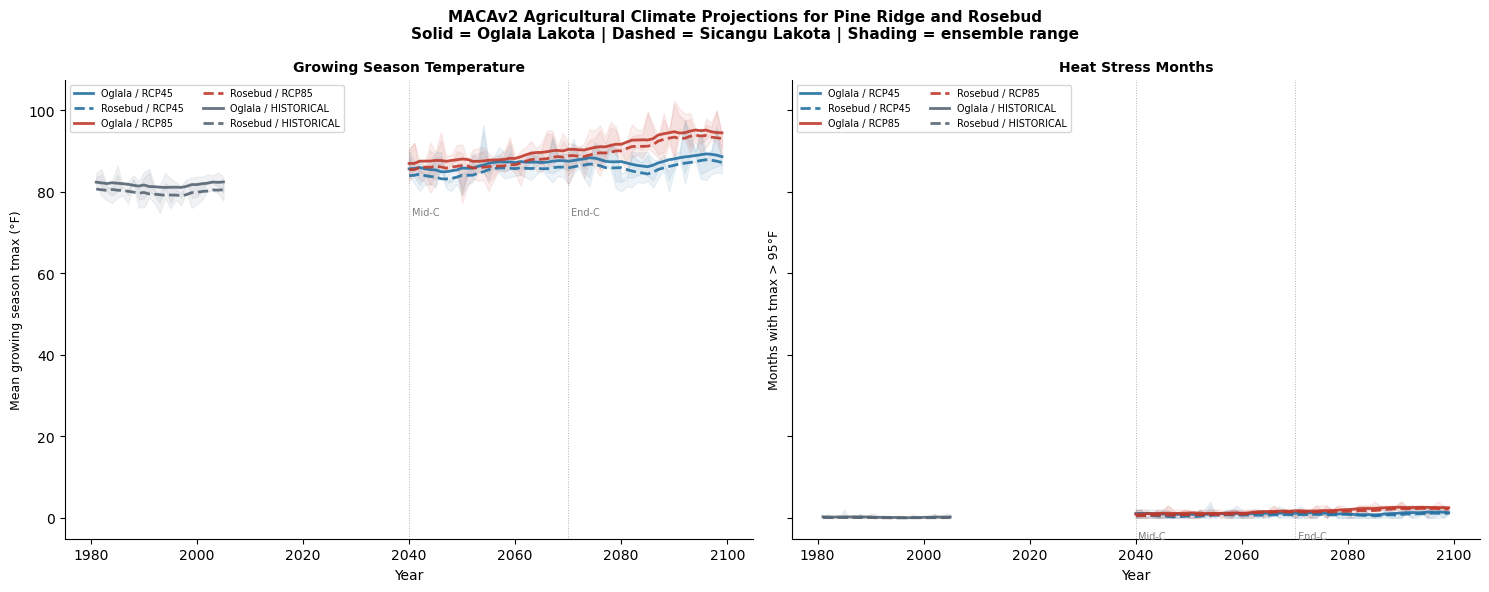

In [11]:
# Time series: growing season tmax for primary Tribes
SCENARIO_COLORS = {"rcp45": "#2471A3", "rcp85": "#C0392B", "historical": "#566573"}
TRIBE_STYLES    = {"Oglala Lakota": "-", "Rosebud Sioux": "--"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, metric, ylabel, title in zip(
    axes,
    ["tmax_f_mean",        "heat_stress_months"],
    ["Mean growing season tmax (°F)", "Months with tmax > 95°F"],
    ["Growing Season Temperature",    "Heat Stress Months"],
):
    for scenario, color in SCENARIO_COLORS.items():
        for name in SD_TRIBES_PRIMARY:
            grp = (
                gs_annual[
                    (gs_annual["common_name"] == name) &
                    (gs_annual["scenario"] == scenario)
                ]
                .groupby("year")[metric].mean()
                .reset_index()
            )
            if grp.empty:
                continue
            ls = TRIBE_STYLES.get(name, "-")
            # 10-year rolling mean
            grp["smooth"] = grp[metric].rolling(10, center=True, min_periods=1).mean()
            ax.fill_between(
                grp["year"],
                gs_annual[
                    (gs_annual["common_name"] == name) &
                    (gs_annual["scenario"] == scenario)
                ].groupby("year")[metric].min().reset_index()[metric],
                gs_annual[
                    (gs_annual["common_name"] == name) &
                    (gs_annual["scenario"] == scenario)
                ].groupby("year")[metric].max().reset_index()[metric],
                color=color, alpha=0.08,
            )
            ax.plot(
                grp["year"], grp["smooth"],
                color=color, linewidth=2, linestyle=ls, alpha=0.9,
                label=f"{name.split()[0]} / {scenario.upper()}",
            )

    # Period dividers
    for yr, lbl in [(MID_START, "Mid-C"), (END_START, "End-C")]:
        ax.axvline(yr, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)
        ax.text(yr + 0.5, ax.get_ylim()[0] * 1.01, lbl, fontsize=7, color="gray")

    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    sns.despine(ax=ax)

plt.suptitle(
    "MACAv2 Agricultural Climate Projections for Pine Ridge and Rosebud\n"
    "Solid = Oglala Lakota | Dashed = Sicangu Lakota | Shading = ensemble range",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
try:
    fig_dir = constants.OUTPUTS_DIR / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_dir / "07_climate_projections_time_series.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

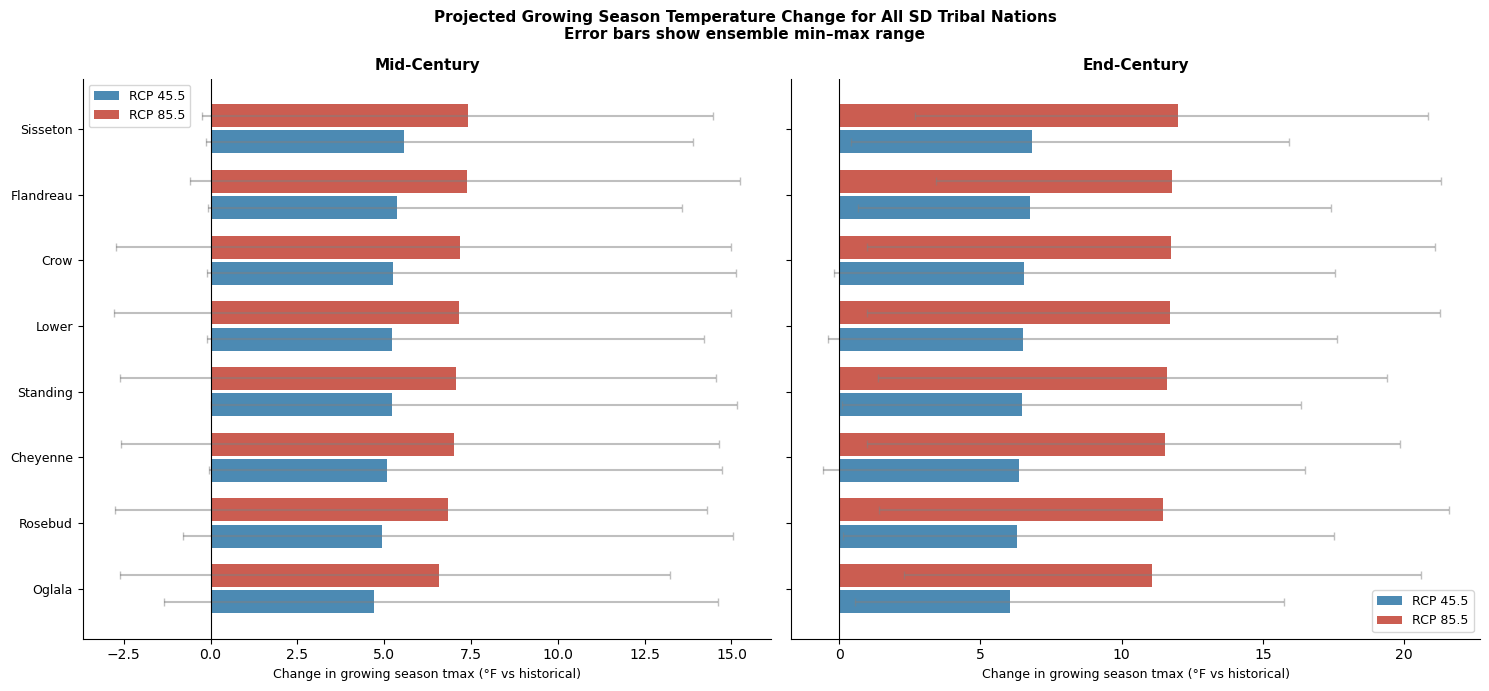

In [12]:
# Change from baseline for all SD Tribes to mid/end century 
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

for ax, period in zip(axes, ["Mid-Century", "End-Century"]):
    for scenario, color, offset in [
        ("rcp45", "#2471A3", -0.2),
        ("rcp85", "#C0392B",  0.2),
    ]:
        sub = ensemble[
            (ensemble["period"] == period) &
            (ensemble["scenario"] == scenario)
        ].sort_values("tmax_delta", ascending=True)

        y = np.arange(len(sub))
        ax.barh(
            y + offset, sub["tmax_delta"], 0.35,
            color=color, alpha=0.82,
            xerr=[
                sub["tmax_mean"] - sub["tmax_min"],
                sub["tmax_max"] - sub["tmax_mean"],
            ],
            capsize=3, ecolor="gray",
            error_kw={"alpha": 0.5},
            label=f"RCP {scenario[-2:]}.{scenario[-1:]}",
        )

    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(sub["common_name"].str.split().str[0], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Change in growing season tmax (°F vs historical)", fontsize=9)
    ax.set_title(period, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle(
    "Projected Growing Season Temperature Change for All SD Tribal Nations\n"
    "Error bars show ensemble min–max range",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
try:
    fig.savefig(fig_dir / "07_climate_projections_delta.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

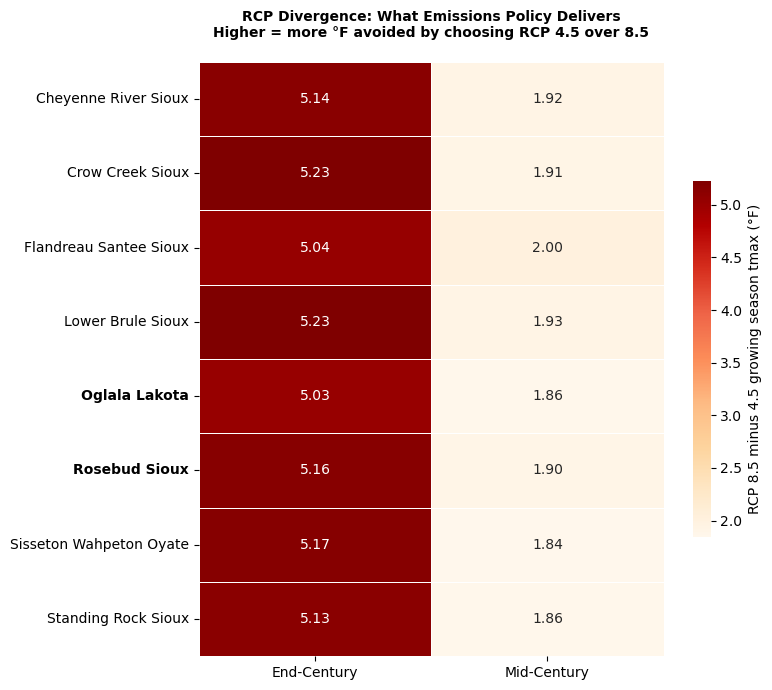

In [20]:
# RCP divergence heatmap
if not divergence_df.empty:
    div_pivot = divergence_df.pivot(
        index="common_name", columns="period", values="tmax_divergence_f"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        div_pivot,
        annot=True, fmt=".2f", cmap="OrRd",
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "RCP 8.5 minus 4.5 growing season tmax (°F)", "shrink": 0.6},
    )
    # Bold primary Tribes
    for label in ax.get_yticklabels():
        if label.get_text() in SD_TRIBES_PRIMARY:
            label.set_fontweight("bold")

    ax.set_title(
        "RCP Divergence: What Emissions Policy Delivers\n"
        "Higher = more °F avoided by choosing RCP 4.5 over 8.5\n",
        fontsize=10, fontweight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    try:
        fig.savefig(fig_dir / "07_rcp_divergence_heatmap.png", dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

## Connection to System Stress Index
Notebook 06 computed the historical SSI from PDSI + NDVI + monitoring gap.
This cell estimates how the drought stress component of the SSI is likely
to change under mid- and end-century scenarios.

In [21]:
# Projected drought stress contribution to SSI
# Higher growing season temperature with unchanged or reduced precipitation
# drives higher PDSI drought stress. This cell shows the projected direction
# of the drought component of the SSI.

print("PROJECTED CHANGES IN AGRICULTURAL CLIMATE STRESS")
print("Connection to System Stress Index (Notebook 06)")

for name in SD_TRIBES_PRIMARY:
    print(f"\n{name}:")
    for period in ["Mid-Century", "End-Century"]:
        for scenario in ["rcp45", "rcp85"]:
            row = ensemble[
                (ensemble["common_name"] == name) &
                (ensemble["period"] == period) &
                (ensemble["scenario"] == scenario)
            ]
            if row.empty:
                continue
            r = row.iloc[0]
            print(
                f"  {period} {scenario.upper()}: "
                f"tmax +{r['tmax_delta']:+.1f}°F | "
                f"precip {r['precip_delta_pct']:+.1f}% | "
                f"heat stress months +{r['heat_months_delta']:+.1f}"
            )

print()
print("Higher temperatures and potentially drier growing seasons = increased")
print("drought stress contribution to SSI. The SSI trend identified in")
print("notebook 06 is likely to intensify under both RCP scenarios.")

PROJECTED CHANGES IN AGRICULTURAL CLIMATE STRESS
Connection to System Stress Index (Notebook 06)

Oglala Lakota:
  Mid-Century RCP45: tmax ++4.7°F | precip +0.5% | heat stress months ++0.9
  Mid-Century RCP85: tmax ++6.6°F | precip +3.0% | heat stress months ++1.1
  End-Century RCP45: tmax ++6.1°F | precip +3.0% | heat stress months ++0.9
  End-Century RCP85: tmax ++11.1°F | precip +0.5% | heat stress months ++2.0

Rosebud Sioux:
  Mid-Century RCP45: tmax ++4.9°F | precip -0.7% | heat stress months ++0.6
  Mid-Century RCP85: tmax ++6.8°F | precip +1.9% | heat stress months ++0.9
  End-Century RCP45: tmax ++6.3°F | precip +3.1% | heat stress months ++0.8
  End-Century RCP85: tmax ++11.5°F | precip -3.1% | heat stress months ++1.8

Higher temperatures and potentially drier growing seasons = increased
drought stress contribution to SSI. The SSI trend identified in
notebook 06 is likely to intensify under both RCP scenarios.


## Exports

In [15]:
try:
    constants.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
except FileExistsError:
    pass

ensemble.to_csv(
    constants.OUTPUTS_DIR / "climate_projections_ensemble.csv", index=False
)
print("Exported to outputs/climate_projections_ensemble.csv")

divergence_df.to_csv(
    constants.OUTPUTS_DIR / "climate_projections_rcp_divergence.csv", index=False
)
print("Exported to outputs/climate_projections_rcp_divergence.csv")

Exported to outputs/climate_projections_ensemble.csv
Exported to outputs/climate_projections_rcp_divergence.csv


## Summary and Findings

*(Fill in after running with your data.)*

**What the data shows:**
- By how many degrees is growing season temperature projected to increase
  on Pine Ridge and Rosebud under RCP 8.5 by end-century? Is that change
  above or below the national average?
- How many additional heat stress months (tmax > 95°F) are projected per
  year? Each additional month of heat stress above this threshold reduces
  cattle and bison weight gain and increases water consumption.
- How does the growing season precipitation trend look? If precipitation
  is decreasing at the same time temperatures are rising, that is a compound
  effect on drought stress and pasture carrying capacity.
- What is the RCP divergence on these lands? The divergence heatmap is the
  most policy-relevant output because it quantifies what national emissions
  reduction policy specifically delivers to each Tribal Nation in avoided
  temperature increase.

**Connection to the series:**
- The historical SSI in notebook 06 is driven by PDSI and NDVI. Both are
  strongly sensitive to growing season temperature and precipitation. The
  projections here indicate the direction and magnitude of change in the
  drivers of the SSI, completing the historical to present to future arc
  of the series.
- The operational pipeline (pipeline track) provides real-time ground
  truth for whether the projected changes are already manifesting in
  observed pasture condition scores and well levels.

**Limitations:**
- Three-model ensemble is lightweight. A 20-model ensemble (all MACAv2
  GCMs) would provide more robust uncertainty bounds.
- MACAv2 is monthly, it does not resolve daily heat events or precipitation
  extremes. For extreme event frequency, daily MACAv2 data or LOCA2
  projections are needed.
- Climate projections carry inherent uncertainty. Present as ranges,
  not single point estimates. The ensemble min–max on the bar charts
  communicates this uncertainty.

**For Tribal decision makers and funders:**
This analysis supports arguments for:
- BIA and USDA climate adaptation planning investments for Tribal rangelands
- Water infrastructure investment justified by projected increased livestock
  water demand under heat stress conditions
- Tribal Climate Resilience Program and RCPP applications
- Connection between national emissions policy and Tribal agricultural futures

In [16]:
print(generate_citations(["census_aiannh", "modis_ndvi"]))
print()
print("MACAv2-METDATA Climate Projections:")
print("  Abatzoglou, J.T. and Brown, T.J. (2012). A comparison of statistical")
print("  downscaling methods suited for wildfire applications. Int. J. Climatology.")
print("  doi:10.1002/joc.2312")
print(f"  Data: {MACA_THREDDS_BASE}")

REFERENCES AND DATA CITATIONS

Census TIGER AIANNH Boundaries:
  US Census Bureau, TIGER/Line Shapefiles (2023).
  URL: https://www.census.gov/cgi-bin/geo/shapefiles/index.php

MODIS Terra Vegetation Indices (MOD13Q1):
  Didan, K. (2021). MODIS/Terra Vegetation Indices 16-Day L3 Global 250m SIN Grid V061. NASA EOSDIS Land Processes DAAC. doi: 10.5067/MODIS/MOD13Q1.061
  URL: https://lpdaac.usgs.gov/products/mod13q1v061/

MACAv2-METDATA Climate Projections:
  Abatzoglou, J.T. and Brown, T.J. (2012). A comparison of statistical
  downscaling methods suited for wildfire applications. Int. J. Climatology.
  doi:10.1002/joc.2312
  Data: http://thredds.northwestknowledge.net:8080/thredds/dodsC/
